# 01 — Analisis Protein Pertama (Ubiquitin + AlphaFold)

Pembelajaran: dari **sekuens** ke **struktur prediksi**, lalu **dibaca oleh Python**.

**Lingkup notebook ini:** latihan analisis data deskriptif.
Ini **bukan** drug discovery, **bukan** validasi eksperimen, dan hasil AlphaFold
adalah **model prediksi** — bukan kebenaran biologis.

**Data:**
- `data/ubiquitin_sequence.fasta` — sekuens input dari sesi AlphaFold Server Anda (±76 residu, pTM 0.86).
- `structures/` — (menunggu diisi) file struktur prediksi `.pdb` / `.cif` hasil unduhan AlphaFold Server.

Jalankan sel satu per satu dengan **Shift+Enter**.


## 1. Apa itu asam amino?

- Protein dibangun dari **20 asam amino standar**.
- Semua asam amino punya tulang punggung yang sama (N—Cα—C), yang berbeda adalah
  **rantai samping** (side chain)-nya.
- Sifat rantai samping (hidrofobik/hidrofilik, bermuatan, besar/kecil) menentukan
  cara protein melipat menjadi bentuk 3D.

| Kode 1 | Kode 3 | Asam amino | Sifat singkat |
|---|---|---|---|
| A | Ala | Alanin | hidrofobik kecil |
| R | Arg | Arginin | bermuatan positif |
| N | Asn | Asparagin | polar |
| D | Asp | Asam aspartat | bermuatan negatif |
| C | Cys | Sistein | bisa membentuk jembatan disulfida |
| Q | Gln | Glutamin | polar |
| E | Glu | Asam glutamat | bermuatan negatif |
| G | Gly | Glisin | paling kecil, fleksibel |
| H | His | Histidin | bisa bermuatan, sering di situs aktif |
| I | Ile | Isoleusin | hidrofobik |
| L | Leu | Leusin | hidrofobik |
| K | Lys | Lisin | bermuatan positif |
| M | Met | Metionin | hidrofobik, kode start |
| F | Phe | Fenilalanin | aromatik, hidrofobik |
| P | Pro | Prolin | kaku, sering di belokan |
| S | Ser | Serin | polar kecil |
| T | Thr | Treonin | polar |
| W | Trp | Triptofan | aromatik besar |
| Y | Tyr | Tirosin | aromatik, bisa terfosforilasi |
| V | Val | Valin | hidrofobik |


## 2. Apa itu protein sequence?

**Sekuens protein** adalah urutan asam amino dari ujung N (N-terminus) ke ujung C
(C-terminus), ditulis sebagai teks huruf satu-kode. Urutannya penting — protein
adalah "kata" biologis; ganti satu huruf saja bisa mengubah segalanya.

Sekuens ubiquitin yang Anda prediksi (76 asam amino):

`MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG`


In [1]:
# Cara Python membaca sekuens dari file FASTA
from pathlib import Path
from Bio import SeqIO

# Root project: notebook bisa dijalankan dari folder notebooks/ maupun dari root project
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

fasta_path = PROJECT_ROOT / "data" / "ubiquitin_sequence.fasta"
with fasta_path.open(encoding="utf-8") as fh:
    record = next(SeqIO.parse(fh, "fasta"))

sequence = str(record.seq).upper()
print("Nama file :", fasta_path)
print("Nama seq  :", record.id)
print("Panjang   :", len(sequence), "asam amino")
print("Sekuens   :", sequence)


Nama file : D:\project\ai-biotech\data\ubiquitin_sequence.fasta
Nama seq  : ubiquitin
Panjang   : 76 asam amino
Sekuens   : MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG


## 3. Apa itu protein structure?

Empat level struktur protein:

1. **Primer** — urutan asam amino (sekuens di atas).
2. **Sekunder** — pola lokal: α-helix, β-sheet, loop.
3. **Tersier** — lipatan 3D lengkap satu rantai. Inilah yang diprediksi AlphaFold.
4. **Kuartener** — gabungan beberapa rantai (ubiquitin sendiri: satu rantai).

Struktur 3D disimpan sebagai **koordinat (x, y, z) tiap atom**.


## 4. Hubungan sequence → structure

- Prinsip klasik (Anfinsen): **urutan menentukan lipatan** — informasi lipatan
  "tersimpan" di dalam sekuens.
- Tapi memprediksi lipatan dari sekuens itu sulit. **AlphaFold belajar pola ini
  dari database struktur eksperimen (PDB).**
- Konsekuensi praktis:
  - sekuens mirip → struktur biasanya mirip;
  - satu mutasi bisa mengubah stabilitas/lipatan (tidak selalu);
  - **prediksi bukan kebenaran** — perlakukan model sebagai hipotesis yang bisa salah.


## 5. Apa itu pLDDT?

**pLDDT** (predicted Local Distance Difference Test) = skor keyakinan AlphaFold
**per residu**, skala 0–100.

| Rentang | Arti praktis |
|---|---|
| > 90 | sangat yakin |
| 70–90 | yakin |
| 50–70 | rendah — hati-hati |
| < 50 | sangat rendah — sering di daerah tak terstruktur (disordered) |

Penting: pLDDT mengukur **keyakinan model**, bukan kualitas biologis protein.
Pada file output AlphaFold, nilai ini disimpan di kolom **B-factor**.


## 6. Apa itu PAE?

**PAE** (Predicted Alignment Error) = matriks 2D residu × residu dengan satuan
ångström (Å). Isinya: perkiraan *error* posisi relatif antar pasangan residu.

- PAE rendah antara dua bagian protein → AlphaFold yakin posisi relatif keduanya.
- pLDDT = kualitas **lokal** per residu; PAE = kualitas **relatif / antar-bagian**
  (misalnya orientasi antar-domain).

Pada hasil AlphaFold Server Anda, PAE tersedia (biasanya file terpisah).
Belum dipakai di tahap ini — ini bahan analisis lanjutan.


## 7. Apa arti pTM?

**pTM** = predicted TM-score: skor keyakinan **global** (topologi keseluruhan),
skala 0–1.

- pTM > 0.5 → lipatan model kira-kira menyerupai struktur asli.
- pTM > 0.8 → keyakinan global tinggi.

Hasil Anda: **pTM = 0.86** untuk rantai ±76 residu → keyakinan global tinggi.
Catatan jujur: protein kecil berdomain tunggal memang sering mendapat skor tinggi,
jadi angka bagus **bukan bukti otomatis** bahwa prediksi benar secara biologis.


## 8. Bagaimana Python membaca struktur protein?

Dua format file yang umum:

- **PDB (.pdb)** — format lama, teks dengan kolom tetap.
- **mmCIF (.cif)** — standar baru, lebih kaya informasi.

Dengan **Biopython**, isi file dibaca sebagai hierarki objek:

```
Structure
 +-- Model        (bisa lebih dari satu; di project ini kita pakai model pertama)
      +-- Chain   (.id)
           +-- Residue   (.get_resname(), .id)
                +-- Atom     (.get_coord(), .get_bfactor())
```

Beberapa perintah yang sering dipakai:

- `parser.get_structure(...)` — membaca file
- `chain.id`, `res.get_resname()` — identitas chain/residu
- `atom.get_coord()` — koordinat 3D (numpy array)
- `atom.get_bfactor()` — nilai B-factor (pLDDT pada output AlphaFold)

Script `src/analyze_protein.py` sudah membungkus semua ini — kita pakai langsung di bawah.


In [2]:
# Cek apakah file struktur sudah tersedia di folder structures/
struct_dir = PROJECT_ROOT / "structures"
struct_files = sorted(
    p for p in struct_dir.glob("*")
    if p.suffix.lower() in {".pdb", ".cif", ".mmcif"}
)

print("Folder    :", struct_dir)
print("Ditemukan :", len(struct_files), "file struktur")
for p in struct_files:
    print("  -", p.name)

if not struct_files:
    print()
    print("Belum ada file struktur. Letakkan file .pdb / .cif hasil unduhan")
    print("AlphaFold Server ke folder structures/, lalu jalankan ulang notebook ini.")
    print("Contoh: structures/ubiquitin_alphafold.pdb")


Folder    : D:\project\ai-biotech\structures
Ditemukan : 0 file struktur

Belum ada file struktur. Letakkan file .pdb / .cif hasil unduhan
AlphaFold Server ke folder structures/, lalu jalankan ulang notebook ini.
Contoh: structures/ubiquitin_alphafold.pdb


In [3]:
# Statistik sekuens memakai fungsi dari script project (src/analyze_protein.py)
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from analyze_protein import analyze_sequence

seq_stats = analyze_sequence(sequence)
print("Panjang        :", seq_stats["length"], "asam amino")
print("Berat molekul  :", seq_stats.get("molecular_weight_da"), "Da (perkiraan)")
print("GRAVY          :", seq_stats.get("gravy"), "(- hidrofilik, + hidrofobik)")

import pandas as pd
df = pd.DataFrame(
    list(seq_stats["composition"].items()), columns=["asam_amino", "jumlah"]
)
print()
print(df.to_string(index=False))


Panjang        : 76 asam amino
Berat molekul  : 8564.7 Da (perkiraan)
GRAVY          : -0.489 (- hidrofilik, + hidrofobik)



asam_amino  jumlah
         L       9
         I       7
         K       7
         T       7
         E       6
         G       6
         Q       6
         D       5
         R       4
         V       4
         P       3
         S       3
         A       2
         F       2
         N       2
         H       1
         M       1
         Y       1


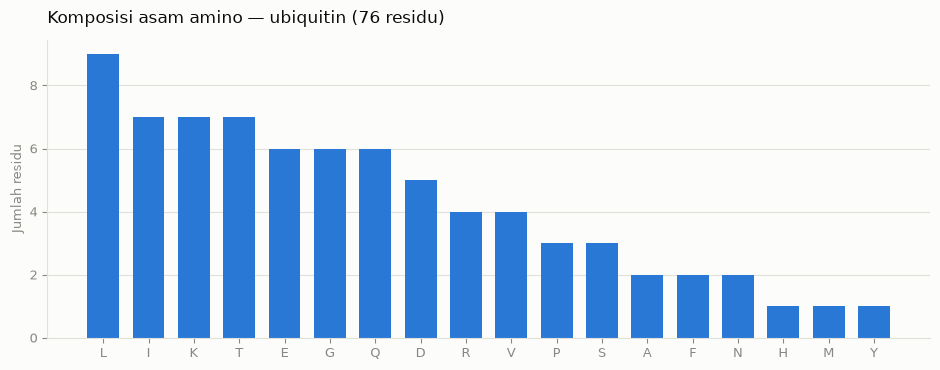

In [4]:
# Grafik komposisi — satu seri data, jadi satu warna (bukan warna berbeda per kategori)
%matplotlib inline
import matplotlib.pyplot as plt

INK_PRIMARY = "#0b0b0b"   # teks utama
INK_MUTED   = "#898781"   # label sumbu
GRID        = "#e1e0d9"   # garis bantu (redup)
BAR         = "#2a78d6"   # warna seri (satu-satunya)
SURFACE     = "#fcfcfb"   # latar chart

aas  = list(seq_stats["composition"].keys())
vals = list(seq_stats["composition"].values())

fig, ax = plt.subplots(figsize=(9.5, 3.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(range(len(aas)), vals, color=BAR, width=0.7)

ax.set_xticks(range(len(aas)), aas)
ax.set_title(
    f"Komposisi asam amino — ubiquitin ({len(sequence)} residu)",
    color=INK_PRIMARY, fontsize=12, loc="left", pad=12,
)
ax.set_ylabel("Jumlah residu", color=INK_MUTED, fontsize=9)
ax.tick_params(colors=INK_MUTED, labelsize=9)

ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)

plt.tight_layout()
plt.show()


In [5]:
# Jika file struktur sudah ada, baca dan ringkas (pakai fungsi dari src/analyze_protein.py)
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from analyze_protein import analyze_structure

if struct_files:
    summary, per_residue = analyze_structure(struct_files[0])
    print("File    :", summary["file"])
    print("Format  :", summary["format"])
    print("Chains  :", summary["n_chains"])
    print("Residu  :", summary["total_residues"])
    for c in summary["chains"]:
        print(f"\n  chain '{c['chain_id']}': {c['n_residues']} residu, {c['n_atoms']} atom")
        st = c.get("bfactor_plddt_stats")
        if st:
            print(f"    B-factor/pLDDT rata-rata : {st['mean']}")
            print(f"    residu pLDDT >= 70       : {st['frac_ge_70'] * 100:.1f}%")
            print(f"    residu pLDDT >= 90       : {st['frac_ge_90'] * 100:.1f}%")
else:
    summary, per_residue = None, None
    print("(Lewati — belum ada file struktur di structures/.)")


(Lewati — belum ada file struktur di structures/.)


In [6]:
# Grafik pLDDT per residu (muncul hanya jika file struktur tersedia)
INK_PRIMARY = "#0b0b0b"
INK_MUTED   = "#898781"
GRID        = "#e1e0d9"
BAR         = "#2a78d6"
SURFACE     = "#fcfcfb"

if per_residue:
    import pandas as pd
    df_res = pd.DataFrame(per_residue)

    fig, ax = plt.subplots(figsize=(9.5, 3.4), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    ax.plot(df_res["res_id"], df_res["bfactor_plddt"], color=BAR, linewidth=2)

    ax.axhline(90, color=GRID, linewidth=1, linestyle="--")
    ax.axhline(70, color=GRID, linewidth=1, linestyle="--")
    ax.text(0.995, 0.90, "pLDDT 90", transform=ax.transAxes, ha="right", va="bottom",
            color=INK_MUTED, fontsize=8)
    ax.text(0.995, 0.70, "pLDDT 70", transform=ax.transAxes, ha="right", va="bottom",
            color=INK_MUTED, fontsize=8)

    ax.set_title("pLDDT per residu (dibaca dari kolom B-factor)",
                 color=INK_PRIMARY, fontsize=12, loc="left", pad=12)
    ax.set_xlabel("Nomor residu", color=INK_MUTED, fontsize=9)
    ax.set_ylabel("pLDDT", color=INK_MUTED, fontsize=9)
    ax.set_ylim(0, 100)
    ax.tick_params(colors=INK_MUTED, labelsize=9)

    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

    plt.tight_layout()
    plt.show()
else:
    print("(Lewati — grafik pLDDT muncul setelah file struktur ada di structures/.)")


(Lewati — grafik pLDDT muncul setelah file struktur ada di structures/.)


## 9. Langkah berikutnya

**Untuk Anda (data):** unduh hasil AlphaFold Server, letakkan file struktur ke
`structures/`, lalu jalankan ulang notebook + script ini.

**Untuk pipeline (tahap berikutnya):**

1. Analisis struktur lengkap — script `src/analyze_protein.py` sudah siap.
2. Feature extraction per-residu — mis. pLDDT, hidrofobisitas jendela, frekuensi asam amino.
3. Gabungkan beberapa protein → dataset tabular kecil.
4. Baru setelah itu: eksperimen ML sederhana.

**Yang selalu diingat:**

- Prediksi ≠ kebenaran biologis; ini bukan drug discovery.
- Tidak ada docking / dinamika molekuler / eksperimen basah di project ini.
- Fokus tahap ini: pipeline data yang benar dan bisa dijalankan ulang.
